## **Rede Perceptron — Classificação de Clientes**

Vicente Piltcher, Michele Ughini e Ghabriel Molina

Classificar clientes como bom ou mau pagador  
usando Renda e Dívida como atributos de entrada.
- **70%** dos dados → Treinamento  
- **30%** dos dados → Teste

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

## 1. Carregamento e Análise dos Dados

In [2]:
df = pd.read_csv('dados.csv')
print('Shape:', df.shape)
print()
print(df)
print()
print('Distribuição das classes:')
print(df['Classe'].value_counts())

Shape: (21, 4)

    Cliente  Renda  Divida Classe
0       101   2800     550    bom
1       102   1300     500    mau
2       103   1400      80    bom
3       104    500     200    mau
4       105   1100     270    mau
5       106   1800     450    bom
6       107   2400     650    bom
7       108   1950     600    bom
8       109    450      70    mau
9       110   2750     730    bom
10      111    850      90    mau
11      112   1300     200    mau
12      113   2100     750    bom
13      114    900     300    mau
14      115   2700     250    bom
15      116   1600     500    mau
16      117   1900     150    bom
17      118   2500     800    bom
18      119   1600     700    mau
19      120   2300     500    bom
20      121   2100     250    bom

Distribuição das classes:
Classe
bom    12
mau     9
Name: count, dtype: int64


## 2. Seleção de Atributos

- **Renda**: quanto maior a renda, maior a chance de ser bom pagador
- **Dívida**: quanto maior a dívida em relação à renda, maior o risco
- **Classe**: 1 -> Bom, 0 -> Mau

In [3]:
X = df[['Renda', 'Divida']].values
y = df['Classe'].map({'bom': 1, 'mau': 0}).values

print('Entradas (X):'); print(X)
print('Saídas  (y):', y)

Entradas (X):
[[2800  550]
 [1300  500]
 [1400   80]
 [ 500  200]
 [1100  270]
 [1800  450]
 [2400  650]
 [1950  600]
 [ 450   70]
 [2750  730]
 [ 850   90]
 [1300  200]
 [2100  750]
 [ 900  300]
 [2700  250]
 [1600  500]
 [1900  150]
 [2500  800]
 [1600  700]
 [2300  500]
 [2100  250]]
Saídas  (y): [1 0 1 0 0 1 1 1 0 1 0 0 1 0 1 0 1 1 0 1 1]


## 3. Normalização

Renda varia de ~450 a 2800 e Dívida de ~70 a 800.
A normalização traz tudo para o intervalo **[0, 1]**:

In [4]:
x_min = X.min(axis=0)
x_max = X.max(axis=0)

X_norm = (X - x_min) / (x_max - x_min)

print('Min por coluna:', x_min)
print('Max por coluna:', x_max)
print()
print('Dados normalizados:')
print(np.round(X_norm, 3))

Min por coluna: [450  70]
Max por coluna: [2800  800]

Dados normalizados:
[[1.    0.658]
 [0.362 0.589]
 [0.404 0.014]
 [0.021 0.178]
 [0.277 0.274]
 [0.574 0.521]
 [0.83  0.795]
 [0.638 0.726]
 [0.    0.   ]
 [0.979 0.904]
 [0.17  0.027]
 [0.362 0.178]
 [0.702 0.932]
 [0.191 0.315]
 [0.957 0.247]
 [0.489 0.589]
 [0.617 0.11 ]
 [0.872 1.   ]
 [0.489 0.863]
 [0.787 0.589]
 [0.702 0.247]]


## 4. Divisão Treino / Teste (70% / 30%)

In [5]:
random.seed(42)
n = len(X_norm)
indices = list(range(n))
random.shuffle(indices)

n_treino = int(n * 0.7)
n_teste  = n - n_treino

idx_treino = indices[:n_treino]
idx_teste  = indices[n_treino:]

# Tuplas
dados_treino = [[X_norm[i][0], X_norm[i][1], y[i]] for i in idx_treino]
dados_teste  = [[X_norm[i][0], X_norm[i][1], y[i]] for i in idx_teste]

print(f'Total de amostras : {n}')
print(f'Amostras treino   : {n_treino}')
print(f'Amostras teste    : {n_teste}')
print()
print('Dados de treino (x1_norm, x2_norm, classe):')
for d in dados_treino:
    print(f'  Renda={d[0]:.3f}  Divida={d[1]:.3f}  Classe={d[2]}')

Total de amostras : 21
Amostras treino   : 14
Amostras teste    : 7

Dados de treino (x1_norm, x2_norm, classe):
  Renda=0.787  Divida=0.589  Classe=1
  Renda=0.574  Divida=0.521  Classe=1
  Renda=0.957  Divida=0.247  Classe=1
  Renda=0.277  Divida=0.274  Classe=0
  Renda=0.979  Divida=0.904  Classe=1
  Renda=0.191  Divida=0.315  Classe=0
  Renda=0.489  Divida=0.589  Classe=0
  Renda=0.489  Divida=0.863  Classe=0
  Renda=0.830  Divida=0.795  Classe=1
  Renda=0.702  Divida=0.932  Classe=1
  Renda=0.872  Divida=1.000  Classe=1
  Renda=0.170  Divida=0.027  Classe=0
  Renda=0.362  Divida=0.589  Classe=0
  Renda=0.362  Divida=0.178  Classe=0


## 5. Funções do Perceptron na mesma topologia da atividade anterior

In [6]:
def funcaoLimiar(v):
    return 1 if v >= 0 else 0

def propagacao(tupla, pesos):
    v = pesos[0] + pesos[1] * tupla[0] + pesos[2] * tupla[1]
    return v

def algoritmoTreinamento(dados, eta=0.1, max_epocas=200):
    pesos = [0.0, 0.0, 0.0]
    print('Pesos iniciais:', pesos)
    erros_por_epoca = []

    for epoca in range(1, max_epocas + 1):
        erroGeral = 0
        for tupla in dados:
            v = propagacao(tupla, pesos)
            y = funcaoLimiar(v)
            erro = tupla[2] - y
            if erro != 0:
                pesos[0] += eta * erro
                pesos[1] += eta * erro * tupla[0]
                pesos[2] += eta * erro * tupla[1]
            erroGeral += abs(erro)

        erros_por_epoca.append(erroGeral)
        if erroGeral == 0:
            print(f'Convergiu na época {epoca}!')
            break
    else:
        print(f'Atingiu {max_epocas} épocas sem convergir total (erro final={erroGeral})')

    print('Pesos finais:', [round(p, 4) for p in pesos])
    return pesos, erros_por_epoca

## 6. Treinamento

Pesos iniciais: [0.0, 0.0, 0.0]
Convergiu na época 50!
Pesos finais: [np.float64(-0.3), np.float64(0.6915), np.float64(-0.1863)]


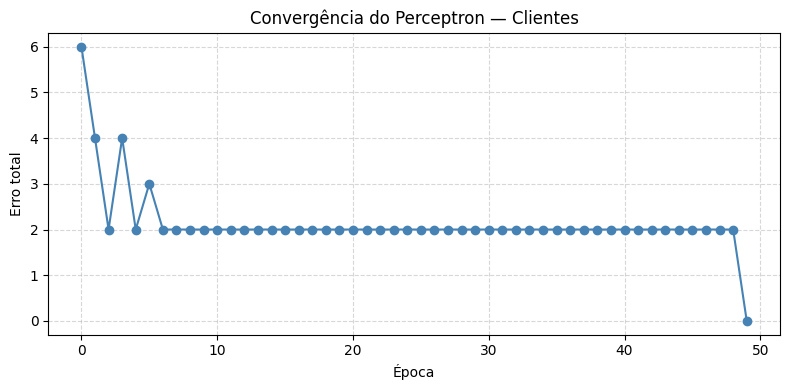

In [7]:
pesos, historico_erros = algoritmoTreinamento(dados_treino, eta=0.1, max_epocas=200)

# pedi pra IA fazer o gráfico
plt.figure(figsize=(8, 4))
plt.plot(historico_erros, marker='o', color='steelblue')
plt.xlabel('Época')
plt.ylabel('Erro total')
plt.title('Convergência do Perceptron — Clientes')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Teste e Desempenho

In [10]:
print('=' * 55)
print(f'  {"Cliente":>8}  {"Renda":>8}  {"Divida":>8}  {"Real":>5}  {"Pred":>5}  {"OK?":>4}')
print('=' * 55)

acertos = 0
for i, tupla in zip(idx_teste, dados_teste):
    v = propagacao(tupla, pesos)
    pred = funcaoLimiar(v)
    real = int(tupla[2])
    ok = 'OK' if pred == real else 'NOT OK'
    if pred == real:
        acertos += 1
    cliente = df.iloc[i]['Cliente']
    renda   = df.iloc[i]['Renda']
    divida  = df.iloc[i]['Divida']
    classe_real = 'bom' if real == 1 else 'mau'
    classe_pred = 'bom' if pred == 1 else 'mau'
    print(f'  {cliente:>8}  {renda:>8}  {divida:>8}  {classe_real:>5}  {classe_pred:>5}  {ok}')

print('=' * 55)
acuracia = acertos / n_teste * 100
print(f'Acertos : {acertos}/{n_teste}')
print(f'Acurácia: {acuracia:.1f}%')

   Cliente     Renda    Divida   Real   Pred   OK?
       103      1400        80    bom    mau  NOT OK
       117      1900       150    bom    bom  OK
       108      1950       600    bom    bom  OK
       109       450        70    mau    mau  OK
       101      2800       550    bom    bom  OK
       104       500       200    mau    mau  OK
       121      2100       250    bom    bom  OK
Acertos : 6/7
Acurácia: 85.7%


## 8. Visualização — Fronteira de Decisão

/tmp/ipykernel_1371/3916992150.py:41: UserWarning: Glyph 11096 (\N{HEAVY CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11096 (\N{HEAVY CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


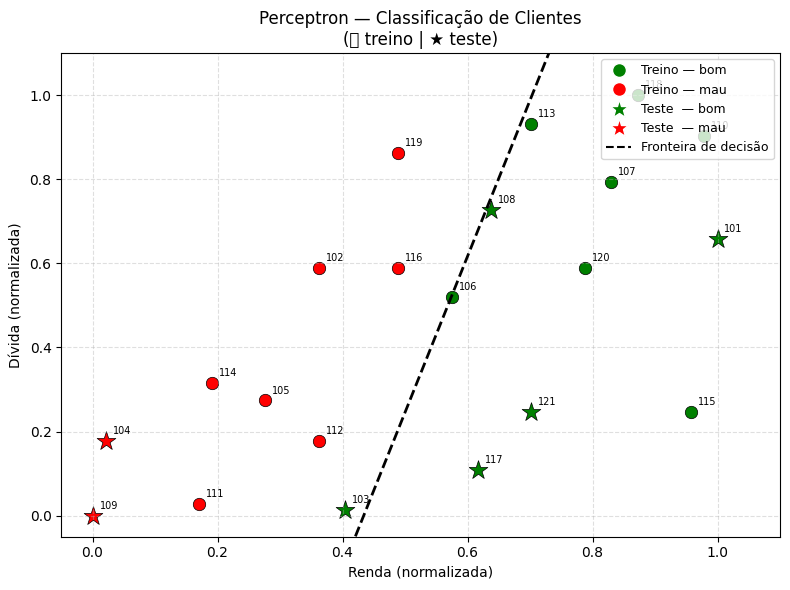

In [9]:
#Mais um gráfico gerado com IA

w0, w1, w2 = pesos

fig, ax = plt.subplots(figsize=(8, 6))

# Plotar todos os pontos (treino=círculo, teste=estrela)
for i in range(n):
    cor    = 'green' if y[i] == 1 else 'red'
    marker = 'o' if i in idx_treino else '*'
    size   = 80   if i in idx_treino else 200
    ax.scatter(X_norm[i][0], X_norm[i][1], c=cor, marker=marker,
               s=size, edgecolors='black', linewidths=0.5)
    ax.annotate(str(df.iloc[i]['Cliente']),
                (X_norm[i][0], X_norm[i][1]),
                textcoords='offset points', xytext=(5, 5), fontsize=7)

# Reta de separação: w0 + w1*x1 + w2*x2 = 0  →  x2 = (-w0 - w1*x1) / w2
x_line = np.linspace(-0.05, 1.05, 200)
if w2 != 0:
    y_line = (-w0 - w1 * x_line) / w2
    ax.plot(x_line, y_line, 'k--', linewidth=2, label='Fronteira de decisão')
else:
    ax.axvline(x=-w0/w1, color='black', linestyle='--', label='Fronteira de decisão')

# Legenda manual
from matplotlib.lines import Line2D
legenda = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Treino — bom'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='red',   markersize=10, label='Treino — mau'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor='green', markersize=14, label='Teste  — bom'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor='red',   markersize=14, label='Teste  — mau'),
    Line2D([0],[0], color='black', linestyle='--', label='Fronteira de decisão'),
]
ax.legend(handles=legenda, loc='upper right', fontsize=9)

ax.set_xlim(-0.05, 1.1)
ax.set_ylim(-0.05, 1.1)
ax.set_xlabel('Renda (normalizada)')
ax.set_ylabel('Dívida (normalizada)')
ax.set_title('Perceptron — Classificação de Clientes\n(⭘ treino | ★ teste)')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()